# qBraid Support - QBraidExecutor

This page introduces [qBraid](https://www.qbraid.com/) support in Qamomile and shows how to run a Qamomile workflow with `QBraidExecutor`. Qamomile currently connects to qBraid through its Qiskit integration, so the usual flow is `qkernel` -> `QiskitTranspiler` -> `QBraidExecutor`.

## What this notebook shows
This notebook is a tutorial with `QBraidExecutor` built around a MaxCut workflow. The main goal is to show how to configure `QBraidExecutor`, transpile a qkernel with `QiskitTranspiler`, reuse the same remote executor throughout the optimization loop, and inspect the final samples returned by qBraid.

## Installation

Install the qBraid integration with the optional `qbraid` dependency group:

```bash
pip install "qamomile[qbraid]"
```

This installs Qamomile together with the qBraid package and its Qiskit integration.

In [ ]:
import warnings
from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.optimize import minimize

import qamomile.circuit as qmc
from qamomile.circuit.algorithm.qaoa import qaoa_state
from qamomile.optimization.binary_model.expr import VarType
from qamomile.optimization.binary_model.model import BinaryModel
from qamomile.qbraid import QBraidExecutor
from qamomile.qiskit import QiskitTranspiler

seed = 901
rng = np.random.default_rng(seed)

## qBraid Setup
qBraid provides a unified interface for running quantum programs on supported simulators and hardware backends. In Qamomile, `QBraidExecutor` is the piece that submits Qiskit circuits to a qBraid device, waits for the remote job to finish, and returns the results in the same format as other Qamomile executors.

In this notebook, we create the executor first and then reuse it for both parameter optimization and the final evaluation step. The warning filter below is scoped to this setup cell only, so it suppresses the known `pyqir` runtime warning without affecting unrelated warnings elsewhere in the notebook.

**Note:** Replace `"YOUR_API_KEY"` in the cell below with your own qBraid API key. You can find your API key on the [qBraid account page](https://account.qbraid.com/).

In [ ]:
device_id = "qbraid:qbraid:sim:qir-sv"
api_key = "YOUR_API_KEY"

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=r"The default runtime configuration for device 'qbraid:qbraid:sim:qir-sv' includes transpilation to program type 'pyqir', which is not registered\.",
        category=RuntimeWarning,
        module=r"qbraid\.runtime\.native\.provider",
    )
    qbraid_executor = QBraidExecutor(
        device_id=device_id,
        api_key=api_key,
    )

## MaxCut Example
With the qBraid executor ready, we now prepare a single parameterized QAOA program for MaxCut and use qBraid to sample it repeatedly during optimization. The overall flow is graph construction -> Ising model -> parameterized QAOA qkernel -> Qiskit transpilation -> qBraid sampling -> solution analysis.

### Constructing the problem
We use `networkx.random_regular_graph` to create a small random 3-regular graph with 8 nodes as the MaxCut instance. This graph is the classical input data that will later be encoded into a QAOA circuit and sampled on qBraid. The figure is only a visualization of the problem structure; the optimization itself uses the graph data.

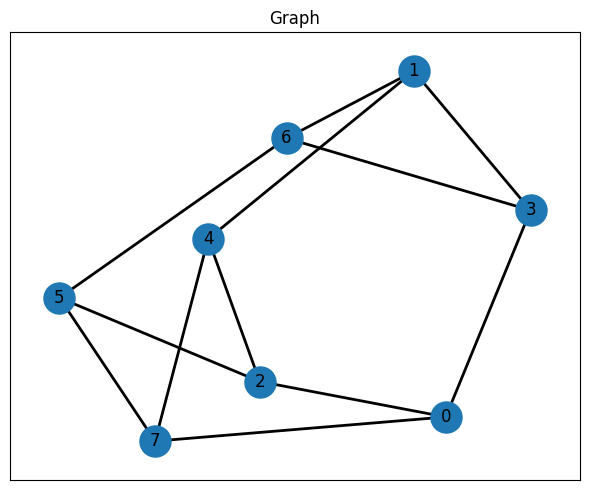

In [ ]:
# Create a random graph using networkx
graph = nx.random_regular_graph(d=3, n=8, seed=seed)

# Visualize the random graph
fig, ax = plt.subplots(figsize=(6, 5))
ax.set_title("Graph")
pos = nx.spring_layout(graph, seed=seed)
nx.draw_networkx(graph, pos, ax=ax, node_size=500, width=2, with_labels=True)
plt.tight_layout()
plt.show()

### Constructing the Ising Hamiltonian
MaxCut can be written as an Ising optimization problem in which an edge contributes when its two endpoints are assigned to opposite spin states. In this construction, each graph edge adds a quadratic interaction term, while the constant term shifts the objective so that minimizing the Ising energy corresponds to maximizing the cut value. After building the spin model, `normalize_by_rms()` rescales the coefficients to a comparable magnitude, which is often helpful before repeatedly sampling the corresponding QAOA circuit on qBraid.

In [ ]:
quad = {}
linear = {node: 0.0 for node in graph.nodes()}
constant = 0.0

for u, v, data in graph.edges(data=True):
    key = (u, v) if u <= v else (v, u)
    quad[key] = quad.get(key, 0.0) + 1 / 2
    constant -= 1 / 2

spin_model = BinaryModel.from_ising(linear=linear, quad=quad, constant=constant)
spin_model_normalized = spin_model.normalize_by_rms()
spin_model_normalized._expr

BinaryExpr(vartype=<VarType.SPIN: 'SPIN'>, constant=np.float64(-12.0), coefficients={(0,): np.float64(0.0), (1,): np.float64(0.0), (2,): np.float64(0.0), (3,): np.float64(0.0), (4,): np.float64(0.0), (5,): np.float64(0.0), (6,): np.float64(0.0), (7,): np.float64(0.0), (0, 7): np.float64(1.0), (0, 3): np.float64(1.0), (0, 2): np.float64(1.0), (1, 4): np.float64(1.0), (1, 6): np.float64(1.0), (1, 3): np.float64(1.0), (2, 4): np.float64(1.0), (2, 5): np.float64(1.0), (3, 6): np.float64(1.0), (4, 7): np.float64(1.0), (5, 7): np.float64(1.0), (5, 6): np.float64(1.0)})

### Constructing the QAOA circuit
`qaoa_state(...)` builds the layered QAOA ansatz for the Ising model, and `qmc.measure(q)` turns the state preparation circuit into a sampling qkernel that returns measured bits. We then transpile the qkernel with `QiskitTranspiler`, binding the fixed problem data once while leaving `gammas` and `betas` as variational parameters.

In [ ]:
@qmc.qkernel
def qaoa_circuit(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = qaoa_state(p=p, quad=quad, linear=linear, n=n, gammas=gammas, betas=betas)
    return qmc.measure(q)

In [ ]:
transpiler = QiskitTranspiler()
p = 5  # Number of QAOA layers

executable = transpiler.transpile(
    qaoa_circuit,
    bindings={
        "p": p,
        "quad": spin_model_normalized.quad,
        "linear": spin_model_normalized.linear,
        "n": len(graph.nodes()),
    },
    parameters=["gammas", "betas"],
)

### Optimization
The objective function evaluates one candidate parameter vector at a time. For each trial, it binds `gammas` and `betas`, sends the executable to qBraid through `QBraidExecutor`, converts the sampled bitstrings into binary energies, and averages those energies to estimate the objective value. `scipy.optimize.minimize(...)` handles the outer classical search, while qBraid sampling provides the measurement data that drives each update. The same executor is reused across all iterations, which keeps the remote execution path explicit throughout the optimization loop.

In [ ]:
# List to save optimization history
energy_history = []
# Convert the spin model into the corresponding binary model to evaluate
# the energy of the sampled bitstrings
binary_model = spin_model.change_vartype(VarType.BINARY)


# Define the objective function for optimization
def objective_function(params, executable, executor, shots=2000):
    """
    Objective function for QAOA parameter optimization.

    Args:
        params: Concatenated [gammas, betas] parameters
        executable: Compiled QAOA circuit
        executor: Executor used for circuit sampling
        shots: Number of measurement shots

    Returns:
        Estimated mean energy
    """
    p = len(params) // 2
    gammas = params[:p]
    betas = params[p:]

    # Sample the circuit with the current parameters using the provided executor.
    job = executable.sample(
        executor,
        bindings={
            "gammas": gammas,
            "betas": betas,
        },
        shots=shots,
    )
    result = job.result()

    # Calculate the average energy from the sampled bitstrings
    energies = []
    for bit_list, counts in result.results:
        energy = binary_model.calc_energy(bit_list)
        for _ in range(counts):
            energies.append(energy)
    energy_avg = np.average(energies)
    energy_history.append(energy_avg)

    return energy_avg

In [ ]:
init_params = rng.uniform(low=-np.pi / 4, high=np.pi / 4, size=2 * p)

# Clear history
energy_history = []

print(f"Starting QAOA optimization with p={p} layers...")
print(f"Initial parameters: gammas={init_params[:p]}, betas={init_params[p:]}")

# Optimize with COBYLA method
result_opt = minimize(
    objective_function,
    init_params,
    # QBraidExecutor is used as the executor for sampling in the objective function
    args=(executable, qbraid_executor),
    method="COBYLA",
    options={"disp": True},
)

print("\nOptimized parameters:")
print(f"  gammas: {result_opt.x[:p]}")
print(f"  betas: {result_opt.x[p:]}")
print(f"Final energy: {result_opt.fun:.4f}")

Starting QAOA optimization with p=5 layers...
Initial parameters: gammas=[ 0.35076764  0.685864   -0.23260876  0.55643368  0.13513932], betas=[-0.51593692  0.46886025 -0.72964494 -0.30084649 -0.58317504]
Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 86   Least value of F = -8.344
The corresponding X is:
[ 1.40667878  0.5369532   0.69483197  1.6757995  -0.02714964 -0.21405772
  0.35435012 -0.60134886  0.82291545 -0.64525361]


Optimized parameters:
  gammas: [ 1.40667878  0.5369532   0.69483197  1.6757995  -0.02714964]
  betas: [-0.21405772  0.35435012 -0.60134886  0.82291545 -0.64525361]
Final energy: -8.3440


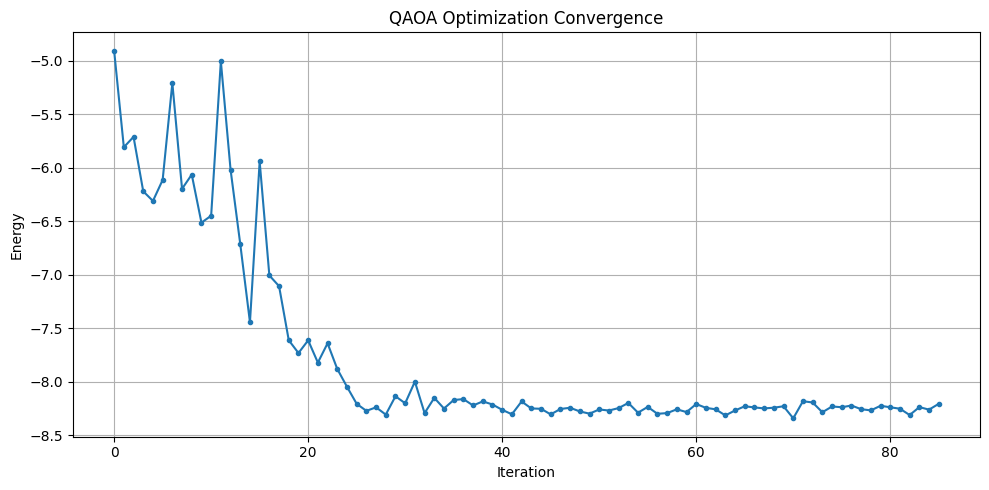

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(energy_history, marker="o", markersize=3)
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("QAOA Optimization Convergence")
plt.grid(True)
plt.tight_layout()
plt.show()

### Evaluation
After the optimization step, we call qBraid one more time with the optimized parameters and collect a larger sample of measurement outcomes. This lets us inspect the final energy distribution, identify the lowest-energy bitstring observed in the remote samples, and interpret that bitstring as a MaxCut solution on the original graph.

In [ ]:
# Sample with optimized parameters
optimal_gammas = result_opt.x[:p]
optimal_betas = result_opt.x[p:]

job_final = executable.sample(
    # Use the same QBraidExecutor to sample the final distribution with optimized parameters
    qbraid_executor,
    bindings={
        "gammas": optimal_gammas,
        "betas": optimal_betas,
    },
    shots=2000,
)
result_final = job_final.result()

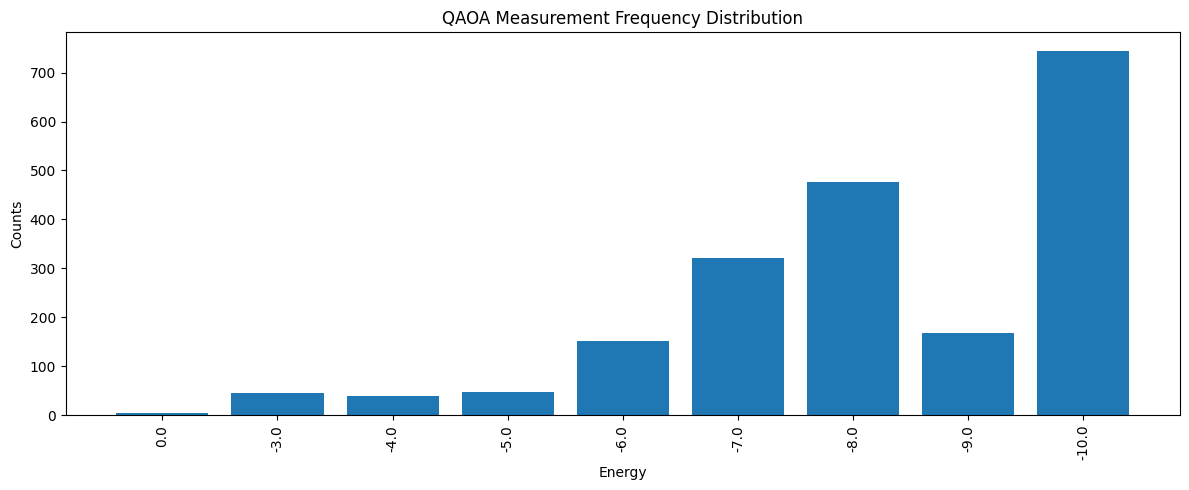

In [ ]:
# Build frequency distribution over all sampled bitstrings
energy_vs_counts = defaultdict(int)
lowest_energy = float("inf")
best_solution = None
for bit_list, counts in result_final.results:
    energy = binary_model.calc_energy(bit_list)
    energy_vs_counts[energy] += counts
    if energy < lowest_energy:
        lowest_energy = energy
        best_solution = bit_list

# Extract energies and counts for plotting
energies = list(energy_vs_counts.keys())
counts = list(energy_vs_counts.values())
# Sort by energy for better visualization
sorted_indices = np.argsort(energies)[::-1]
counts = np.array(counts)[sorted_indices]
energies = np.array(energies)[sorted_indices]

# Plot frequency distribution
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(energy_vs_counts))
bars = ax.bar(x_pos, counts)

ax.set_xticks(x_pos)
ax.set_xticklabels(energies, rotation=90)
ax.set_xlabel("Energy")
ax.set_ylabel("Counts")
ax.set_title("QAOA Measurement Frequency Distribution")
plt.tight_layout()
plt.show()

In [ ]:
# Define functions to visualize the solution on the graph.
def get_edge_colors(
    graph, solution: list[int], in_cut_color: str = "r", not_in_cut_color: str = "b"
) -> tuple[list[str], list[str]]:
    cut_set_1 = [node for node, value in enumerate(solution) if value == 1.0]
    cut_set_2 = [node for node in graph.nodes() if node not in cut_set_1]

    edge_colors = []
    for u, v, _ in graph.edges(data=True):
        if (u in cut_set_1 and v in cut_set_2) or (u in cut_set_2 and v in cut_set_1):
            edge_colors.append(in_cut_color)
        else:
            edge_colors.append(not_in_cut_color)
    node_colors = [
        "#2696EB" if node in cut_set_1 else "#EA9b26" for node in graph.nodes()
    ]
    return edge_colors, node_colors


def show_solution(graph, solution, title):
    edge_colors, node_colors = get_edge_colors(graph, solution)
    cut_edges = sum(1 for c in edge_colors if c == "r")
    _, ax = plt.subplots(figsize=(6, 5))
    ax.set_title(f"{title} (Cut edges: {cut_edges})")
    nx.draw_networkx(
        graph,
        pos,
        ax=ax,
        node_size=500,
        width=3,
        with_labels=True,
        edge_color=edge_colors,
        node_color=node_colors,
    )
    plt.tight_layout()
    plt.show()

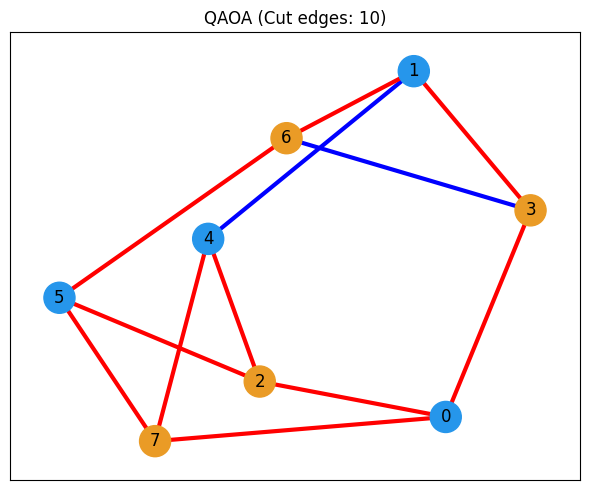

In [ ]:
# Visualize the best solution found by QAOA
show_solution(graph, best_solution, "QAOA")

## Optional Classical Comparison
The main qBraid workflow ends above. The final section is an optional comparison against a classical optimizer built with [JijModeling](https://jij-inc-jijmodeling-tutorials-en.readthedocs-hosted.com/en/latest/introduction.html) and `OMMXPySCIPOptAdapter`. This provides a reference solution for the same MaxCut instance and helps us judge how good the QAOA result is.

In [ ]:
import jijmodeling as jm
from ommx_pyscipopt_adapter import OMMXPySCIPOptAdapter

In [ ]:
# Define the MaxCut problem using JijModeling
problem = jm.Problem("Maxcut", sense=jm.ProblemSense.MAXIMIZE)


@problem.update
def _(problem: jm.DecoratedProblem):
    V = problem.Dim()
    E = problem.Graph()
    x = problem.BinaryVar(shape=(V,))

    obj = (
        E.rows()
        .map(lambda e: 1 / 2 * (1 - (2 * x[e[0]] - 1) * (2 * x[e[1]] - 1)))
        .sum()
    )
    problem += obj


problem

Problem(name="Maxcut", sense=MAXIMIZE, objective=sum(E.rows().map(lambda (e: Tuple[natural, natural]): 0.5 * (1 - (2 * x[e[0]] - 1) * (2 * x[e[1]] - 1)))), constraints=[])

In [ ]:
# Create the OMMX instance from the graph data.
V = graph.number_of_nodes()
E = graph.edges()
data = {"V": V, "E": E}
print(data)
instance = problem.eval(data)

{'V': 8, 'E': EdgeView([(0, 7), (0, 3), (0, 2), (1, 4), (1, 6), (1, 3), (2, 4), (2, 5), (3, 6), (4, 7), (5, 7), (5, 6)])}


In [ ]:
# Solve the problem with OMMXPySCIPOptAdapter
scip_solution = OMMXPySCIPOptAdapter.solve(instance)
scip_solution_entries = [bit for bit in scip_solution.state.entries.values()]
print(f"SCIP Solution: {scip_solution_entries}")

SCIP Solution: [0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0]


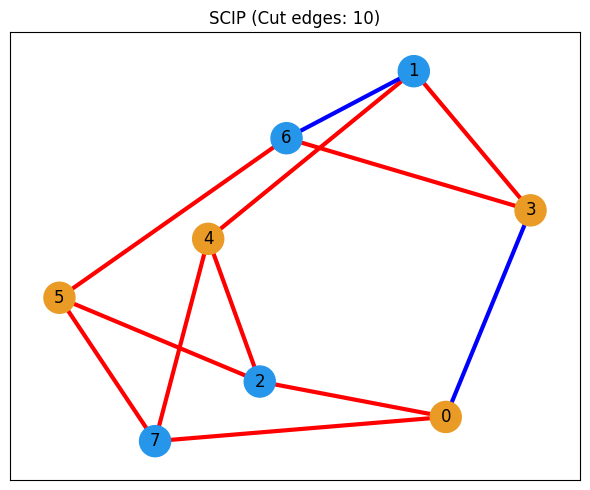

In [ ]:
# Visualize the solution found by SCIP
show_solution(graph, scip_solution_entries, "SCIP")

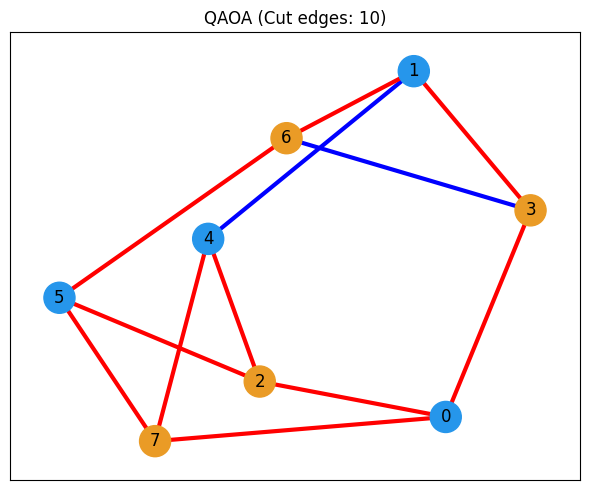

In [ ]:
# Visualize the best solution found by QAOA again for comparison
show_solution(graph, best_solution, "QAOA")